# Loading and Visualizing Raster Data

Every analysis in this cookbook starts from a bathymetry grid stored as a GeoTIFF file. Before we can compute terrain derivatives or map seabed features, we need to read that file into Python, understand how its pixels relate to real-world positions, and display it. The library that does this is [rasterio](https://rasterio.readthedocs.io/).

This notebook is a practical introduction to rasterio. It covers opening a raster, reading its metadata, pulling the pixel values into a NumPy array, and converting between pixel and map coordinates. For visualization it then hands off to the modern raster stack, `rioxarray` and `xarray-spatial`, so you never have to hand-write terrain math.

## Overview

1. What a georeferenced raster is: an array plus a coordinate reference system and an affine transform.
2. Opening a dataset and inspecting its metadata.
3. Reading band values into a NumPy array, including nodata handling.
4. Converting between pixel indices and map coordinates.
5. Visualizing a raster with `rioxarray`, `xarray-spatial`, and Matplotlib's `LightSource`.
6. A reusable function for loading and visualizing bathymetric geotiffs.

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [NumPy arrays](https://foundations.projectpythia.org/core/numpy.html) | Necessary | Raster bands are NumPy arrays |
| [Matplotlib](https://foundations.projectpythia.org/core/matplotlib.html) | Helpful | Used for all plots |
| Coordinate reference systems | Helpful | Rasters carry a CRS and a transform |
| {doc}`seabed-morphology` | Helpful | Why bathymetry grids matter here |

- **Time to learn**: 30 minutes

---

## Imports

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource, Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.ticker as mticker

import rasterio
from rasterio.plot import plotting_extent

# rioxarray registers the .rio accessor on xarray objects when imported
import rioxarray
from xrspatial import hillshade

# Tick formatter without scientific notation
formatter = mticker.FuncFormatter(lambda x, pos: f"{int(x):,}")

## What is a raster?

A raster is a regular grid of cells, or pixels, where each cell holds a value. A bathymetry raster holds a water-depth value in every cell. On its own, that grid is just a 2D array of numbers. What makes it a *georeferenced* raster, and not an ordinary image, is two extra pieces of information:

1. A **coordinate reference system** (CRS) that says which place on Earth the grid covers and in what units.
2. An **affine transform** that maps each cell's (row, column) position to a real-world (x, y) coordinate.

A raster can also hold several **bands**, which are stacked grids of the same size. A satellite image might have red, green, and blue bands; our bathymetry files have a single band. rasterio gives you access to all three parts: the array, the CRS, and the transform.

## Opening a dataset

`rasterio.open` returns a dataset object. Opening a file does not read the pixel values; it reads only the header, so it is cheap even for very large rasters. We will use the Gifford Canyon bathymetry that ships with this cookbook.

In [2]:
data_path = Path("../data/gifford_bathy.tif")

dataset = rasterio.open(data_path)
dataset

<open DatasetReader name='../data/gifford_bathy.tif' mode='r'>

:::{tip}
In scripts, open a dataset inside a `with rasterio.open(path) as dataset:` block so the file is closed automatically. Here we keep the handle open across several cells for interactive exploration, then close it explicitly at the end.
:::

## Inspecting the metadata

The dataset object exposes the georeferencing as plain attributes. These are the values you will reach for most often.

In [3]:
print("CRS         :", dataset.crs)
print("Dimensions  :", dataset.width, "x", dataset.height, "(cols x rows)")
print("Band count  :", dataset.count)
print("Data types  :", dataset.dtypes)
print("Nodata value:", dataset.nodata)
print("Bounds      :", dataset.bounds)
print("Resolution  :", dataset.res)
print()
print("Affine transform:")
print(dataset.transform)

CRS         : EPSG:32757
Dimensions  : 914 x 835 (cols x rows)
Band count  : 1
Data types  : ('float32',)
Nodata value: 3.3999999521443642e+38
Bounds      : BoundingBox(left=515475.0, bottom=7026925.0, right=561175.0, top=7068675.0)
Resolution  : (50.0, 50.0)

Affine transform:
| 50.00, 0.00, 515475.00|
| 0.00,-50.00, 7068675.00|
| 0.00, 0.00, 1.00|


The CRS tells you the map projection and units (metres, here). The resolution is the size of one cell in those units. The transform is the affine matrix that ties pixels to coordinates; we use it in a moment.

For convenience, the whole georeferencing header is available as a single dictionary, the dataset *profile*. This is exactly what you pass back to rasterio when writing a new file.

In [4]:
dict(dataset.profile)

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': 3.3999999521443642e+38,
 'width': 914,
 'height': 835,
 'count': 1,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 57S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",159],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32757"]]'),
 'transform': Affine(50.0, 0.0, 515475.0,
        0.0, -50.0, 7068675.0),
 'blockxsize': 914,
 'blockysize': 2,
 'tiled': False,
 'interleave': 'band'}

## Reading pixel values into an array

`dataset.read(1)` reads the first band into a NumPy array. Band indices are 1-based, following the GeoTIFF convention. The array's shape is (rows, columns).

In [5]:
band1 = dataset.read(1)
print("type :", type(band1).__name__)
print("shape:", band1.shape)
print("dtype:", band1.dtype)

type : ndarray
shape: (835, 914)
dtype: float32


Rasters use a sentinel **nodata** value to mark cells with no measurement, such as gaps between survey lines. If you read naively, those sentinels pollute any statistic you compute. Passing `masked=True` returns a masked array in which nodata cells are hidden.

In [6]:
bathy_data = dataset.read(1, masked=True)
bathy_data

masked_array(
  data=[[--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        ...,
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --]],
  mask=[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],
  fill_value=3.4e+38,
  dtype=float32)

For numerical work it is often easiest to convert the masked cells to `NaN` and use the `np.nan*` family of functions, which skip `NaN` automatically.

In [7]:
bathy_nan = bathy_data.filled(np.nan)

print("shallowest:", np.nanmax(bathy_nan), "m")
print("deepest   :", np.nanmin(bathy_nan), "m")
print("mean depth:", np.nanmean(bathy_nan), "m")

shallowest: -255.59682 m
deepest   : -3221.865 m
mean depth: -1839.3173 m


## Pixel and map coordinates

The affine transform is what separates a georeferenced raster from a plain image. It converts a (row, column) pixel index into an (x, y) map coordinate. rasterio wraps this in two convenience methods so you rarely touch the matrix directly: `xy` goes from pixel to map, and `index` goes from map to pixel.

In [8]:
# Pixel (row, col) -> map (x, y)
row, col = 200, 300
x, y = dataset.xy(row, col)
print(f"pixel (row={row}, col={col}) -> map (x={x:.1f}, y={y:.1f})")

# Map (x, y) -> pixel (row, col)
r, c = dataset.index(x, y)
print(f"map (x={x:.1f}, y={y:.1f}) -> pixel (row={r}, col={c})")

pixel (row=200, col=300) -> map (x=530500.0, y=7058650.0)
map (x=530500.0, y=7058650.0) -> pixel (row=200, col=300)


:::{note}
Under the hood, `xy` is applying the affine transform `dataset.transform * (col, row)`, and `index` applies its inverse. The helper methods also account for whether a coordinate refers to a cell's centre or corner, which is easy to get wrong by hand.
:::

We are done with the low-level handle, so we close it.

In [9]:
dataset.close()

## Visualizing a raster

You *could* plot the array straight from rasterio with `imshow`, but then the axes are in pixel indices, not map coordinates, and you would have to build a hillshade by hand. The modern approach is to load the same file with `rioxarray`, which returns an `xarray.DataArray` that carries the coordinates and CRS with it. Labelled plotting and terrain shading then come for free.

`open_rasterio` returns a DataArray with a leading band dimension; `squeeze` drops it for our single-band file, and `masked=True` applies the nodata mask as `NaN`.

In [10]:
bathy = rioxarray.open_rasterio(data_path, masked=True).squeeze()
bathy

<xarray.DataArray (y: 835, x: 914)> Size: 3MB
[763190 values with dtype=float32]
Coordinates:
    band         int64 8B 1
  * x            (x) float64 7kB 5.155e+05 5.156e+05 ... 5.611e+05 5.612e+05
  * y            (y) float64 7kB 7.069e+06 7.069e+06 ... 7.027e+06 7.027e+06
    spatial_ref  int64 8B 0
Attributes:
    RASTER_DATASET:  gifford_bathy
    AREA_OR_POINT:   Area
    scale_factor:    1.0
    add_offset:      0.0

Because the array is labelled with `x` and `y` coordinates, a map-aware plot with a colorbar is a single method call.

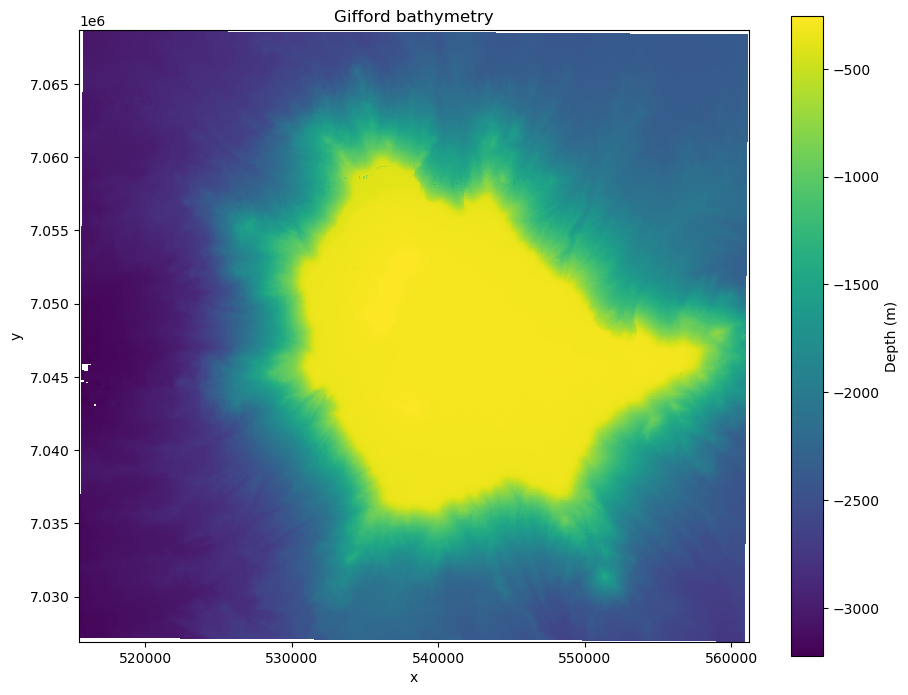

In [11]:
fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
bathy.plot(ax=ax, cmap="viridis", cbar_kwargs={"label": "Depth (m)"})
ax.set_title("Gifford bathymetry")
ax.set_aspect("equal")
plt.show()

### Shaded relief with xarray-spatial

A flat color map hides subtle relief. A **hillshade** simulates illumination from a low sun, which makes ridges and channels pop out. `xarray-spatial` computes it directly from the DataArray, deriving slope and aspect internally, so we do not write any gradient math. `azimuth` is the compass direction of the light source and `angle_altitude` is its height above the horizon.

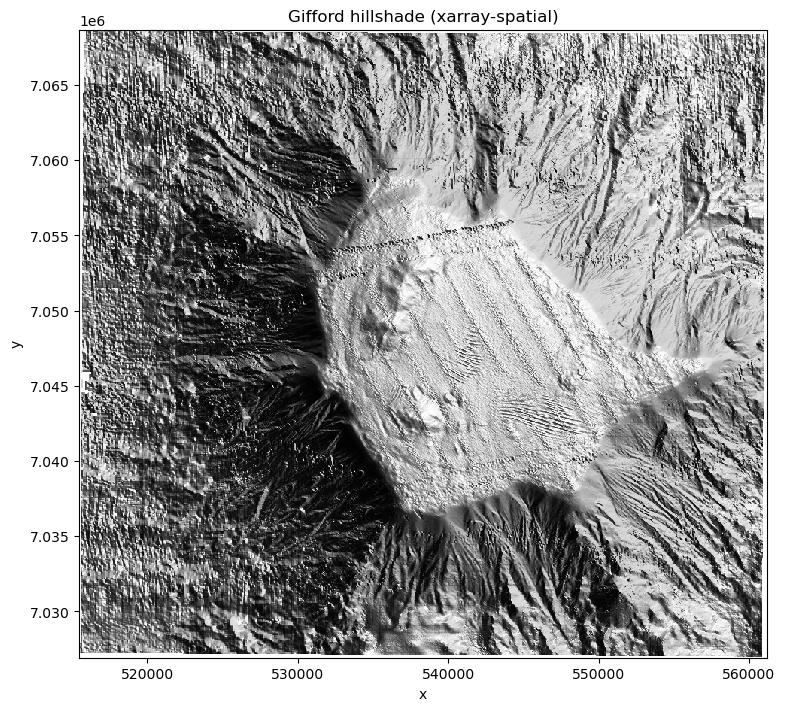

In [12]:
shaded = hillshade(bathy, azimuth=60, angle_altitude=45)

fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
shaded.plot(ax=ax, cmap="gray", add_colorbar=False)
ax.set_title("Gifford hillshade (xarray-spatial)")
ax.set_aspect("equal")
plt.show()

### Color-shaded relief with LightSource

The most readable view blends the depth colormap with the shaded relief. Matplotlib's `LightSource.shade` does this in one call, so again there is no custom shading code. `vert_exag` exaggerates the vertical relief, which helps on the gentle gradients of the seafloor. We read the cell size from the DataArray's `.rio` accessor so the shading respects the true aspect ratio.

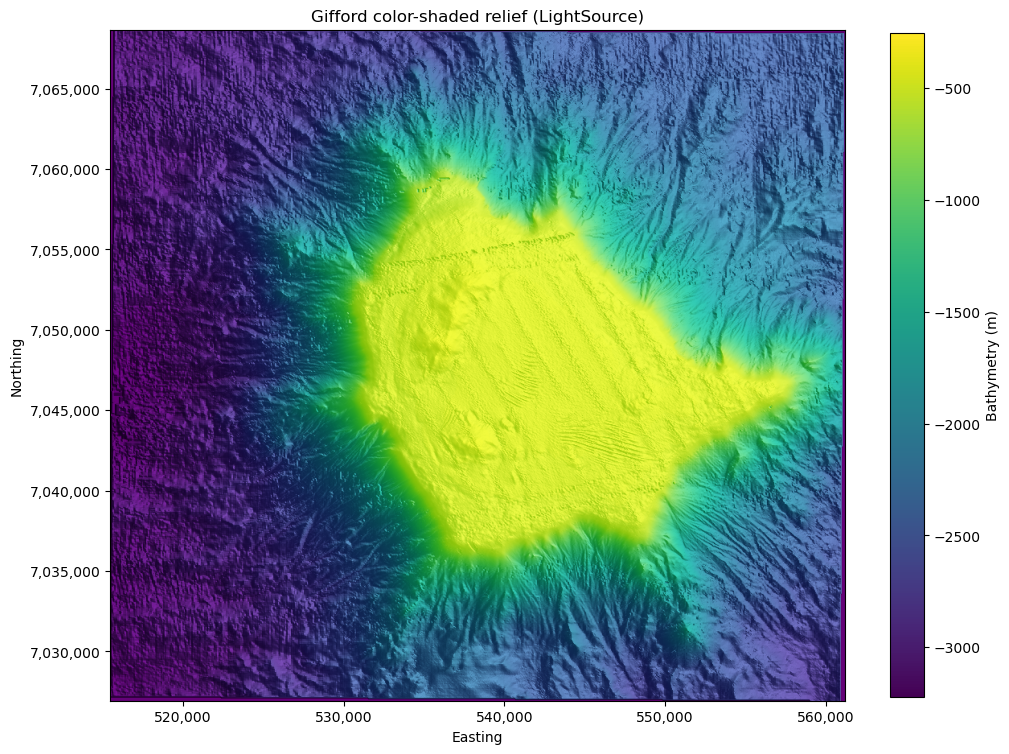

In [14]:
ls = LightSource(azdeg=60, altdeg=45)
dx, dy = bathy.rio.resolution()

z = bathy.values
vmin, vmax = np.nanmin(z), np.nanmax(z)

# remove NaNs for the shading math
filled = np.where(np.isnan(z), vmin, z)          

rgb = ls.shade(
    filled,
    cmap=plt.cm.viridis,
    vmin = vmin,
    vmax = 0,
    vert_exag=50,
    dx=abs(dx),
    dy=abs(dy),
    blend_mode="soft",
)
# make nodata transparent
rgb[np.isnan(z), 3] = 1

extent = plotting_extent(bathy.values, bathy.rio.transform())

# Map-coordinate extent for imshow: (left, right, bottom, top)
left, bottom, right, top = bathy.rio.bounds()

fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
ax.imshow(rgb, extent=(left, right, bottom, top), origin="upper")

norm = Normalize(vmin=float(bathy.min()), vmax=float(bathy.max()))
cbar = fig.colorbar(ScalarMappable(norm=norm, cmap="viridis"), ax=ax, shrink=0.85)
cbar.set_label("Bathymetry (m)")

ax.set_title("Gifford color-shaded relief (LightSource)")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

plt.show()

:::{important} These are two alternatives, not a pipeline
The two cells above are independent ways to make shaded relief, not steps you chain together. `LightSource.shade` computes its own hillshade internally and blends it with the colormap, so you do not pass the `xarray-spatial` result into it.

Pick one:

- For a finished color-and-relief figure in a single call, use `LightSource.shade`.
- Use `xarray-spatial`'s `hillshade` when you want the hillshade as reusable data, for example to save it as its own raster, overlay it manually with `alpha=`, or scale the computation across large Dask-backed arrays.
:::

## A reusable function

The same three steps, load, ## A reusable function

The same three steps, load, shade, and plot, apply to any single-band bathymetry raster. We wrap them in one function and apply it to a second survey, Point Cloates., and plot, apply to any single-band bathymetry raster. We wrap them in one function and apply it to a second survey, Point Cloates.

In [15]:
def plot_shaded_relief(path, title, azimuth=315, altitude=45, vert_exag=5, cmap="viridis"):
    """Load a single-band raster with rioxarray and plot color-shaded relief."""
    da = rioxarray.open_rasterio(path, masked=True).squeeze()

    z = da.values
    vmin, vmax = np.nanmin(z), np.nanmax(z)

    # remove NaNs for the shading math
    filled = np.where(np.isnan(z), vmin, z)  

    ls = LightSource(azdeg=azimuth, altdeg=altitude)
    dx, dy = da.rio.resolution()
    rgb = ls.shade(
        filled, 
        cmap=plt.get_cmap(cmap), 
        vmin=vmin, vmax=0,
        vert_exag=vert_exag,
        dx=abs(dx), dy=abs(dy), blend_mode="soft",
    )

    # make nodata transparent
    rgb[np.isnan(z), 3] = 1

    left, bottom, right, top = da.rio.bounds()
    fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
    ax.imshow(rgb, extent=(left, right, bottom, top), origin="upper")

    norm = Normalize(vmin=float(da.min()), vmax=float(da.max()))
    cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.85)
    cbar.set_label("Bathymetry (m)")

    ax.set_title(title)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)
    return da

## Applying to another survey

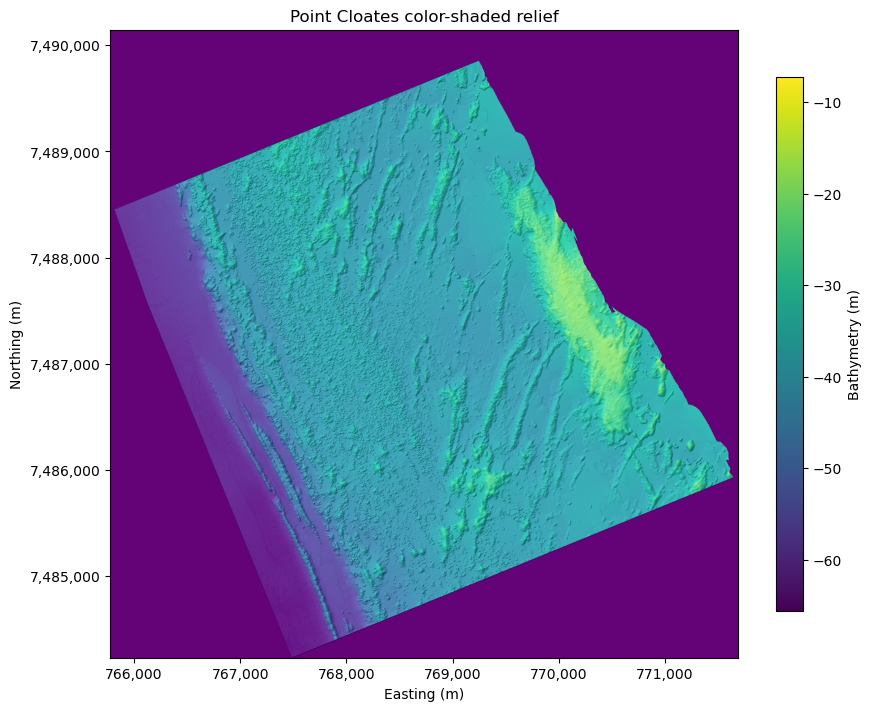

In [16]:
pc_bathy = plot_shaded_relief("../data/pc_bathy.tif", "Point Cloates color-shaded relief")
plt.show()

## Summary

rasterio is the workhorse for reading and writing georeferenced grids. A raster is an array paired with a CRS and an affine transform: the array holds the values, the CRS says where on Earth they sit, and the transform ties pixels to coordinates. You open a file with `rasterio.open`, inspect its metadata through attributes like `crs`, `res`, and `transform`, and pull band values into NumPy with `read`, using `masked=True` to respect nodata. The `xy` and `index` methods convert between pixels and map coordinates. For visualization, loading the file with `rioxarray` gives a labelled, CRS-aware array that plots in map coordinates and feeds either `xarray-spatial` or Matplotlib's `LightSource` for shaded relief, with no hand-written terrain math. Those two are alternatives: `LightSource.shade` already hillshades internally, while `xarray-spatial` gives you the hillshade as reusable data.

### What's next?

With raster reading in hand, the following notebooks compute terrain derivatives such as the Topographic Position Index and use them to delineate and classify seabed features.

## Resources and References

- rasterio documentation: https://rasterio.readthedocs.io/
- rioxarray documentation: https://corteva.github.io/rioxarray/
- xarray-spatial documentation: https://xarray-spatial.readthedocs.io/
- Matplotlib `LightSource`: https://matplotlib.org/stable/api/_as_gen/matplotlib.colors.LightSource.html
- Project Pythia Foundations, NumPy and Matplotlib chapters: https://foundations.projectpythia.org/

## Summary

rasterio is the workhorse for reading and writing georeferenced grids. A raster is an array paired with a CRS and an affine transform: the array holds the values, the CRS says where on Earth they sit, and the transform ties pixels to coordinates. You open a file with `rasterio.open`, inspect its metadata through attributes like `crs`, `res`, and `transform`, and pull band values into NumPy with `read`, using `masked=True` to respect nodata. The `xy` and `index` methods convert between pixels and map coordinates. For visualization, loading the file with `rioxarray` gives a labelled, CRS-aware array that plots in map coordinates and feeds straight into `xarray-spatial` and `LightSource` for shaded relief, with no hand-written terrain math.

### What's next?

With raster reading in hand, the following notebooks compute terrain derivatives such as the Topographic Position Index and use them to delineate and classify seabed features.

## Resources and References

- rasterio documentation: https://rasterio.readthedocs.io/
- rioxarray documentation: https://corteva.github.io/rioxarray/
- xarray-spatial documentation: https://xarray-spatial.readthedocs.io/
- Matplotlib `LightSource`: https://matplotlib.org/stable/api/_as_gen/matplotlib.colors.LightSource.html
- Project Pythia Foundations, NumPy and Matplotlib chapters: https://foundations.projectpythia.org/